PREPARACIÓN DE LOS DATOS
Se hace un merge de los ficheros para unificar la información, se compruba que el merge ha sido exitoso y la distribución de nuestra variable objetivo

In [51]:
import pandas as pd

# 1. Carga de ficheros
train_values = pd.read_csv("xxx")
train_labels = pd.read_csv("xxx1")

# 2. Se hace un merge de ambos archivos para obtener el dataset de trabajo completo
train_df = pd.merge(train_values, train_labels, on='id')

# 3. Comprobación rapida del dataset
print(train_df.head())

# 4. Comprobamos como se reparten los 3 estados de las bombas dentro de nuestros datos
print("\nDistribución de la variable objetivo (status_group):")
print(train_df['status_group'].value_counts(normalize=True))

      id  amount_tsh date_recorded        funder  gps_height     installer  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF   
4  19728         0.0    2011-07-13   Action In A           0       Artisan   

   longitude   latitude              wpt_name  num_private  ... water_quality  \
0  34.938093  -9.856322                  none            0  ...          soft   
1  34.698766  -2.147466              Zahanati            0  ...          soft   
2  37.460664  -3.821329           Kwa Mahundi            0  ...          soft   
3  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  ...          soft   
4  31.130847  -1.825359               Shuleni            0  ...          soft   

  quality_group      quantity  quantity_grou

ANÁLISIS EXPLORATORIO
En este apartado se analiza el dataset con el objetivo de detectar variables problemticas y empezar a plantear soluciones

In [52]:
# 1. Información general del dataset
# Revisamos tipos de datos
print("--- Información General ---")
train_df.info()

# 2. Detección de valores nulos
print("\n--- Valores Nulos por Columna ---")
null_counts = train_df.isnull().sum()
print(null_counts[null_counts > 0])

# 3. Identificación de columnas no utilizables (Alta Cardinalidad o Constantes). Las constantes habrá que eliminarlas pues no aportan información, las de alta cardinalidad han de ser tratadas
print("\n--- Valores Únicos por Columna (Cardinalidad) ---")
print(train_df.nunique().sort_values(ascending=False))

# 4. En la variable constuction year hay muchos valores ceros que en verdad debrian de tratarse como nulos
print("\n--- Valores '0' en construction_year ---")
print((train_df['construction_year'] == 0).sum())

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          594

TRATAMIENTO CARDINALIDAD
La alta cardinalidad en variables categóricas puede sobrecargar el modelo introduciendo mucho ruido lo que puede impedirle generalizar y por ende que su desempeño sea malo. Para ello se ha optado por conservar las 25 categorias que más se repiten y añadir otra llamada "others" agrupando el resto, tras varias pruebas se ha elegido este número de categorías pues es el que ha mostrado mejores resultados

In [53]:
# 1. Identificamos las columnas categóricas actuales
columnas_categoricas = train_df.select_dtypes(include=['object']).columns

# 2. Definimos las excepciones, conservamos la fecha de registro ya qu eno aporta excesiva cardinalidad y tras pruebas he obtenido mejores resultados sin recortarla, lga he decidido conservarla por el mismo motivo, no aporta excesiva cardinalidad y 
# es una division geográfica de un orden superior a ward por lo que puede aportar información de esta otra variable, y status_group es la variable objetivo
excluir = ['date_recorded', 'lga', 'status_group']
variables_a_procesar = [col for col in columnas_categoricas if col not in excluir]

# 3. Reducción de cardinalidad: Top 25 + "others"
for col in variables_a_procesar:
    top_25 = train_df[col].value_counts().nlargest(25).index
    train_df[col] = train_df[col].where(train_df[col].isin(top_25), 'others')

# 4. Verificación del resultado
print("--- Cardinalidad revisada (Top 25 + 'others') ---")
for col in variables_a_procesar:
    print(f"{col}: {train_df[col].nunique()} valores únicos")

--- Cardinalidad revisada (Top 25 + 'others') ---
funder: 26 valores únicos
installer: 26 valores únicos
wpt_name: 26 valores únicos
basin: 9 valores únicos
subvillage: 26 valores únicos
region: 21 valores únicos
ward: 26 valores únicos
public_meeting: 3 valores únicos
recorded_by: 1 valores únicos
scheme_management: 12 valores únicos
scheme_name: 26 valores únicos
permit: 3 valores únicos
extraction_type: 18 valores únicos
extraction_type_group: 13 valores únicos
extraction_type_class: 7 valores únicos
management: 12 valores únicos
management_group: 5 valores únicos
payment: 7 valores únicos
payment_type: 7 valores únicos
water_quality: 8 valores únicos
quality_group: 6 valores únicos
quantity: 5 valores únicos
quantity_group: 5 valores únicos
source: 10 valores únicos
source_type: 7 valores únicos
source_class: 3 valores únicos
waterpoint_type: 7 valores únicos
waterpoint_type_group: 6 valores únicos


TRATAMIENTO NULOS
En este bloque se tratan las variables con valores nulos o incosistentes. 
En primer lugar se convierten en NaN los ceros de las variables longitude, latitude, construction year y gps_height pues no tiene sentido que sean cero.
Se eliminan variables que tras varias pruebas y análisis de importancia han resultado aportar una explicabilidad casi nula, num_private, ward y public_meeting.
Tambien se eliminan las variables scheme_name por que presenta 28810 valores nulos, casi el 50% de los valores, id pues es un simple identificativo y recorded by pues es constante.
Seguidamente se eliminan las observaciones donde wpt_name y subvillage tienen nulos pues son escasas.
El siguiente paso es imputarle a los nulos de funder, installer y scheme-managment el valor "unknown" porque realmente clasificarlo como desconocido puede aportar información relevante, quizá los desconocidos siguen algún patron que el modelo pueda aprovechar.
A partir de aqui preparamos una imputacion de nulos con KNN para ello se transforma permit a dummy para que knn pueda trabajar.
El KNN trabajará y rellenará NaN con las variables 'permit', 'construction_year', 'longitude', 'latitude', 'gps_height' pues considero que la distancia geográfica es lo más adecuado para rellenar los valores nulos además de la legalidad pues intuyo que muchas bombas ilegales se colocaran juntas en zonas donde el control administrativo es escaso.

In [54]:
import numpy as np
from sklearn.impute import KNNImputer

# 1. Tratamiento de inconsistencias: Convertir 0 en NaN
cols_inconsistentes = ['longitude', 'latitude', 'construction_year', 'gps_height']
for col in cols_inconsistentes:
    train_df[col] = train_df[col].replace(0, np.nan)

# 2. Eliminamos varibales con nulo poder explciativo y scheme_name por nulos masivos, id y recorded_by por ser irrelevantes para el modelo
variables_ruido = ['num_private', 'ward', 'public_meeting']
cols_to_drop = ['scheme_name', 'id', 'recorded_by'] + variables_ruido
train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns], inplace=True, errors='ignore')

# Eliminamos nulos marginales de las variables mencionadas en el bloque de texto anterior
train_df.dropna(subset=['wpt_name', 'subvillage'], inplace=True)

# 3. Imputación con unknown a estas variables como se ha mencionado anteriormente
cols_to_unknown = ['funder', 'installer', 'scheme_management']
train_df[cols_to_unknown] = train_df[cols_to_unknown].fillna('unknown')

# 4. IMPUTACIÓN KNN
# Convertimos permit a dummy
train_df['permit'] = train_df['permit'].map({True: 1.0, False: 0.0})

# Definimos el bloque de variables para el KNN
cols_tecnicas_knn = ['permit', 'construction_year', 'longitude', 'latitude', 'gps_height']

knn_imputer = KNNImputer(n_neighbors=5)

# Aplicamos el KNN a todo el bloque
train_df[cols_tecnicas_knn] = knn_imputer.fit_transform(train_df[cols_tecnicas_knn])

# Redondeamos las variables que deben ser enteras (Años y Permit)
train_df['construction_year'] = train_df['construction_year'].round()
train_df['permit'] = train_df['permit'].round()

# Verificación final
print("--- Nulos tras KNN ---")
print(train_df.isnull().sum().sum())
print(f"\nDimensiones finales del dataset: {train_df.shape}")

--- Nulos tras KNN ---
0

Dimensiones finales del dataset: (59400, 35)


FE y TRATAMIENTO CATEGÓRICAS (ENCODING)
Primeramente se transforma la variable date_recorded extrayendo el año y el mes, extraer el mes puede darnos información valiosa por la estacionalidad ya que la bomba se somete a niveles de estrés distintos en temproada seca o humeda.
Para el encoding se han utilizado dos enfoques, target y label encoding. El target encoding (asigna un vector de probabiliades a la categoría según la media de la variable objetivo asociada a ella) se ha usado para las variables, 'funder', 'installer', 'lga', 'ward', 'wpt_name', 'subvillage', pues son las variables de mayor cardinalidad y ha hecho que se obtengan mejores resutlados que con el label encoder (asignar un numero a cada una, 1,2,3...) que se ha usado para el resto de variables. No se ha probado el maximo de combinaciones posibles entre target/label enconder y variables, una posible mejora del modelo podría venir por esta vía.

In [55]:

from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder

# 1. Extraccion de mes y año
train_df['date_recorded'] = pd.to_datetime(train_df['date_recorded'])
train_df['year_recorded'] = train_df['date_recorded'].dt.year
train_df['month_recorded'] = train_df['date_recorded'].dt.month
train_df.drop(columns=['date_recorded'], inplace=True)

# 2. Variables para Target Encoding
cols_target_enc = ['funder', 'installer', 'lga', 'ward', 'wpt_name', 'subvillage']
# Aseguramos que solo procesamos estas
cols_target_enc = [c for c in cols_target_enc if c in train_df.columns]

# Resto categóricas
all_categorical = train_df.select_dtypes(include=['object']).columns
cols_label_enc = [c for c in all_categorical if c not in cols_target_enc and c != 'status_group']

# Diccionarios para guardar los objetos y aplicarlos al test después
target_encoders_dict = {}
label_encoders_dict = {}

# 3. Aplicación de Target Encoding
# El suavizado (smoothing) ayuda a evitar el sobreajuste en categorías con pocos datos
te = TargetEncoder(cols=cols_target_enc, smoothing=10.0)
train_df[cols_target_enc] = te.fit_transform(train_df[cols_target_enc], train_df['status_group'])
target_encoders_dict['main_te'] = te

# 4. Aplicación de Label Encoding
for col in cols_label_enc:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    label_encoders_dict[col] = le

# 5. Verificación de la transformación
print(f"Variables procesadas con Target Encoding: {len(cols_target_enc)}")
print(f"Variables procesadas con Label Encoding: {len(cols_label_enc)}")
print("\nVista previa de las variables Target Encoded (ahora numéricas):")
print(train_df[cols_target_enc].head())

Variables procesadas con Target Encoding: 5
Variables procesadas con Label Encoding: 19

Vista previa de las variables Target Encoded (ahora numéricas):
     funder  installer       lga  wpt_name  subvillage
0  0.740944   0.814185  0.430851  0.502386    0.834312
1  0.740944   0.814185  0.777933  0.869880    0.834312
2  0.740944   0.558824  0.821429  0.859342    0.996016
3  0.771050   0.814185  1.468354  0.859342    0.834312
4  0.740944   0.814185  0.880674  0.935355    0.834312


NORMALIZACIÓN y FE
Para evitar que la señal del modelo se pierda en valores desproporcionadamente grandes de algunas variables y otras muchas pasen desapercibidas por tener valores pequeños se hace una normalización, todas las variables pasan a estar en un rango de 0 a 1 para que el modelo trabaje con las mismas magnitudes y todas las señales sean comparables
Además se crea la nueva variable pump age que es la diferencia entre la fecha de registro y el año de construcción con el objetivo de ayudar al modelo a tener en cuenta este factor con una variable menos, tras pruebas añadir esta variable ha dado mejores resultados

In [56]:
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Creación de 'pump_age'
train_df['pump_age'] = train_df['year_recorded'] - train_df['construction_year']

# Limitamos a 0 por si acaso
train_df['pump_age'] = train_df['pump_age'].clip(lower=0)

# 2. Identificamos las variables numéricas a escalar
cols_continuas = [
    'amount_tsh', 'gps_height', 'longitude', 'latitude', 
    'population', 'month_recorded', 'pump_age'
]

# 3. Escalador
scaler = StandardScaler()

# 4. transformación
train_df[cols_continuas] = scaler.fit_transform(train_df[cols_continuas])

# 5. Eliminamos construction_year y year_recorded pues sus efectos ya están representados en pump_age
train_df.drop(columns=['construction_year', 'year_recorded'], inplace=True, errors='ignore')

# 6. Verificación de resultados
print("\n--- Estadísticos tras el escalado (Media ~0, Std ~1) ---")
print(train_df[cols_continuas].agg(['mean', 'std']).round(2))


--- Estadísticos tras el escalado (Media ~0, Std ~1) ---
      amount_tsh  gps_height  longitude  latitude  population  month_recorded  \
mean        -0.0        -0.0       -0.0       0.0        -0.0             0.0   
std          1.0         1.0        1.0       1.0         1.0             1.0   

      pump_age  
mean      -0.0  
std        1.0  


Antes de crear un modelo y hacer predicciones con el archivo de test, divido el dataset de train en 2 para probar de manera local.

In [57]:
from sklearn.model_selection import train_test_split

# 1. Separamos la variable objetivo
X = train_df.drop(columns=['status_group'])
y = train_df['status_group']

# 2. Realizamos eldivisión train test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 3. Verificación
print(f"X_train (entrenamiento): {X_train.shape}")
print(f"X_test (validación local): {X_test.shape}")

print("En el conjunto original:\n", y.value_counts(normalize=True).round(3))
print("\nEn el conjunto de entrenamiento (X_train):\n", y_train.value_counts(normalize=True).round(3))

X_train (entrenamiento): (47520, 34)
X_test (validación local): (11880, 34)
En el conjunto original:
 status_group
functional                 0.543
non functional             0.384
functional needs repair    0.073
Name: proportion, dtype: float64

En el conjunto de entrenamiento (X_train):
 status_group
functional                 0.543
non functional             0.384
functional needs repair    0.073
Name: proportion, dtype: float64


Modelo inicial random forest. 

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Instanciamos el modelo con n_estimators=100 y random_state para reproducibilidad
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Entrenamiento del modelo
model_rf.fit(X_train, y_train)

# 3. Predicción en el conjunto de validación local (X_test)
y_pred = model_rf.predict(X_test)

# 4. Evaluación inicial
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test, y_pred))


--- Informe de Clasificación ---
                         precision    recall  f1-score   support

             functional       0.82      0.89      0.85      6452
functional needs repair       0.53      0.35      0.42       863
         non functional       0.84      0.79      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.73      0.67      0.69     11880
           weighted avg       0.80      0.81      0.81     11880



Con este bloque he ido comprobando la importancia de las variables de este modo he ido ajustando las variables que he ido usando hasta quedarme con las de este intento.

C:\Users\marti\AppData\Local\Temp\ipykernel_3736\2738129876.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


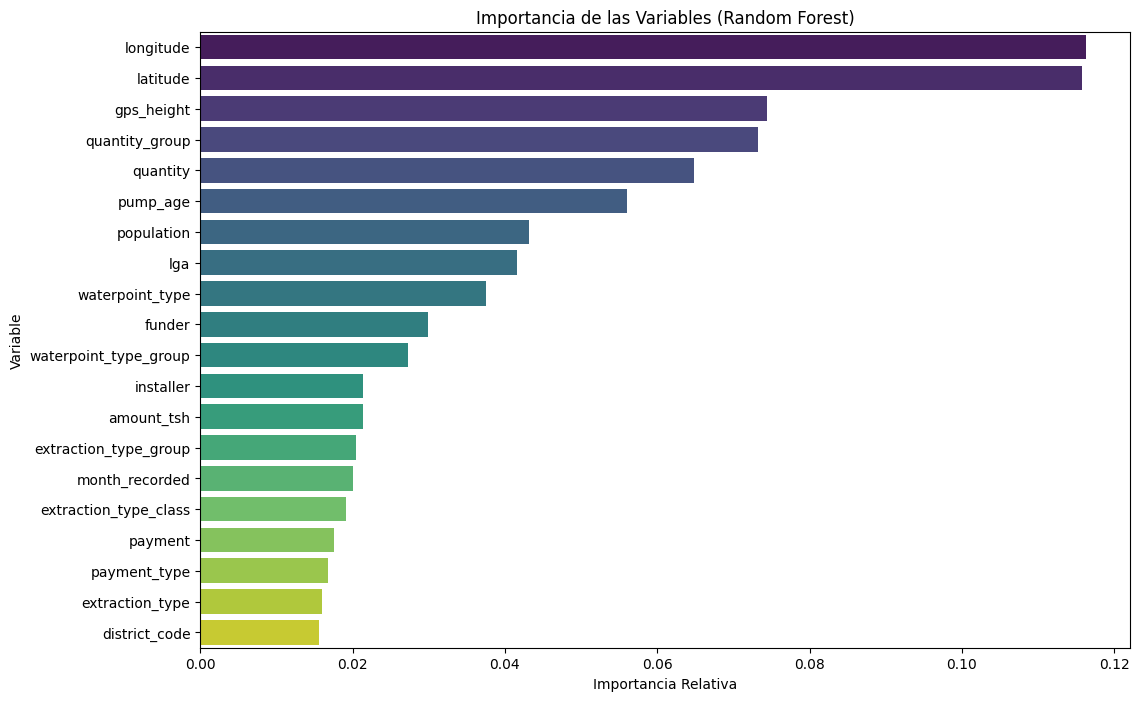

                  Feature  Importance
4               longitude    0.116271
5                latitude    0.115799
2              gps_height    0.074428
26         quantity_group    0.073242
25               quantity    0.064872
33               pump_age    0.056068
13             population    0.043106
12                    lga    0.041601
30        waterpoint_type    0.037530
1                  funder    0.029896
31  waterpoint_type_group    0.027344
3               installer    0.021386
0              amount_tsh    0.021332
17  extraction_type_group    0.020504
32         month_recorded    0.020044
18  extraction_type_class    0.019178
21                payment    0.017628
22           payment_type    0.016752
16        extraction_type    0.015944
11          district_code    0.015636
6                wpt_name    0.015528
27                 source    0.014487
10            region_code    0.013728
9                  region    0.013586
14      scheme_management    0.012379
19          

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraemos la importancia de las variables del modelo entrenado
importances = model_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. Ordenamos de mayor a menor
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Visualización de las Top 20 variables
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Importancia de las Variables (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.show()

# 4. Mostramos todas las variables ordenadas por importancia
print(feature_importance_df)

Anteriormente hemos visto que las clases de la variable objetivo se encuentrna muy desbalanceadas, en este bloque se utiliza la técnica de random oversampling que aleatoriamente duplica observaciones para que las categorias minoritarias igualen en numero a la categoria con mas observaciones (en este caso así se ha hecho). De este modo el modelo podrá aprender mejor cuando la variable objetivo sea una de estas clases minoritarias, anteriormente como había menos observaciones al modelo le sería mas complicado aprender estos casos.
Despues se ejecuta de nuevo el  modelo para comprobar si ha habido mejora respecto al modelo entrenado sin rebalanceo, el accuracy que es nuestra métrica de evaluación en el concurso nha disminuido 1pp., sin embargo las predicciones del concurso han sido mejores usando esta técnica, decidí probarlo en el consurso porque la reducción de 1pp en local no me pareció lo suficientemente significativa como para descartarlo a la primera. Por otro lado se gana algo de sensibilidad a cambio de precisión en la clase de necesita reparación aunque esta no es la metrica de evaluación.

In [60]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier

# 1. Aplicamos el Oversampling al conjunto de TRAIN
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print(f"Distribución antes del balanceo: {y_train.value_counts().to_dict()}")
print(f"Distribución después del balanceo: {y_train_res.value_counts().to_dict()}")

# 2. Re-entrenamos el Random Forest con los datos balanceados
model_rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_bal.fit(X_train_res, y_train_res)

# 3. Predicción y Evaluación
y_pred_bal = model_rf_bal.predict(X_test)

print("\n Informe de Clasificación (Modelo Balanceado)")
print(classification_report(y_test, y_pred_bal))

Distribución antes del balanceo: {'functional': 25807, 'non functional': 18259, 'functional needs repair': 3454}
Distribución después del balanceo: {'functional': 25807, 'non functional': 25807, 'functional needs repair': 25807}

 Informe de Clasificación (Modelo Balanceado)
                         precision    recall  f1-score   support

             functional       0.82      0.85      0.84      6452
functional needs repair       0.44      0.43      0.43       863
         non functional       0.83      0.79      0.81      4565

               accuracy                           0.80     11880
              macro avg       0.70      0.69      0.69     11880
           weighted avg       0.80      0.80      0.80     11880



Tras multiples pruebas con modelos random forest, xgboost y catboost buscando sus mejores hiperparametros con grid search, la combinacion que mejores resutlados ha dado ha sido un voting classifier de randomforest y xgboost dandole al random forest un peso un 20% mayor, además de dar este peso basandome en pruebas, añadir que por separado el random forest ha dado mejores resutlados por lo que lo considero mas fiable. Este método decide el valor de la predicción según los "votos" de cada modelo. Cada modelo hace una predicción dando una probabilidad para cada clase y se hace una media ponderada entre los valores del random forest y xgboost (softvoting). 
Se definen los modelos con sus hiperparametros y se hace el softvoting.
En local la mejora ha sido inexistente sin embargo este enfoque probablemente ha permitido al modelo generalizar mejor y obtener mejores resultados en el dataset de test

In [61]:
from sklearn.ensemble import VotingClassifier
import xgboost as xgb


# 1. Configuración de los modelos base con hiperparámetros optimizados tras grid search y pruebas iterativas
best_rf_params = {
    'n_estimators': 500,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'log2',
    'bootstrap': True,
    'n_jobs': -1,
    'random_state': 42
}

rf_model = RandomForestClassifier(**best_rf_params)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cuda',
    random_state=42
)

# 2. Configuración del Voting Classifier
# Usamos soft voting
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model), 
        ('xgb', xgb_model)
    ],
    voting='soft',
    weights=[1.2, 1]
)


voting_model.fit(X_train_res, y_train_res)

# 3. Evaluación en el conjunto de validación local
y_pred_vote = voting_model.predict(X_test)

print("\n--- Informe de Clasificación (Voting Classifier) ---")
print(classification_report(y_test, y_pred_vote))

# Asignamos el modelo final para que el bloque de Test lo reconozca
best_rf = voting_model


--- Informe de Clasificación (Voting Classifier) ---
                         precision    recall  f1-score   support

             functional       0.83      0.85      0.84      6452
functional needs repair       0.43      0.50      0.46       863
         non functional       0.84      0.80      0.82      4565

               accuracy                           0.80     11880
              macro avg       0.70      0.72      0.71     11880
           weighted avg       0.81      0.80      0.80     11880



En este bloque se aplican las transformaciones hechas anteriormente al dataset de entrenamiento al dataset de test con el objetivo de poder usar el modelo entrenado en este nuevo dataset. Una vez hechas las transformaciones se realizan las predicciones y se exporta a csv. No me detengo a explicar en profundidad lo que se hace porque es exactamenten lo mismo que lo anterior.

In [62]:

import os

# 1. Carga de datos de test y limpieza inicial
test_df = pd.read_csv('test set values.csv')
test_ids = test_df['id']

variables_ruido = ['num_private', 'ward', 'public_meeting']
cols_to_drop = ['id', 'scheme_name', 'recorded_by'] + variables_ruido
test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns], inplace=True)

# 2. Reemplazo de ceros por NaN en las variables que asi lo necesitan como se explicó anteriormente y extracción de fecha
cols_tecnicas = ['longitude', 'latitude', 'construction_year', 'gps_height']
for col in cols_tecnicas:
    if col in test_df.columns:
        test_df[col] = test_df[col].replace(0, np.nan)

if 'date_recorded' in test_df.columns:
    test_df['date_recorded'] = pd.to_datetime(test_df['date_recorded'])
    test_df['year_recorded'] = test_df['date_recorded'].dt.year
    test_df['month_recorded'] = test_df['date_recorded'].dt.month

# 3. Imputación de nulos
test_df['permit'] = test_df['permit'].map({True: 1.0, False: 0.0})
cols_tecnicas_knn = ['permit', 'construction_year', 'longitude', 'latitude', 'gps_height']

test_df[cols_tecnicas_knn] = knn_imputer.transform(test_df[cols_tecnicas_knn])
test_df['construction_year'] = test_df['construction_year'].round()
test_df['permit'] = test_df['permit'].round()

test_df['funder'] = test_df['funder'].fillna('unknown')
test_df['installer'] = test_df['installer'].fillna('unknown')

# 4. Creación de pump_age
test_df['pump_age'] = test_df['year_recorded'] - test_df['construction_year']
test_df['pump_age'] = test_df['pump_age'].clip(lower=0)

# 5. Ecoding
test_df[cols_target_enc] = target_encoders_dict['main_te'].transform(test_df[cols_target_enc])

for col, le in label_encoders_dict.items():
    if col in test_df.columns:
        known_classes = set(le.classes_)
        fallback = le.classes_[0]
        test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known_classes else fallback)
        test_df[col] = le.transform(test_df[col])

# 6. Ecalado
cols_continuas = ['amount_tsh', 'gps_height', 'longitude', 'latitude', 'population', 'month_recorded', 'pump_age']
test_df[cols_continuas] = scaler.transform(test_df[cols_continuas])

# 7. Eliminamos construction_year y year_recorded pues sus efectos ya están representados en pump_age
test_df.drop(columns=['construction_year', 'year_recorded', 'date_recorded'], inplace=True, errors='ignore')
test_df = test_df[X_train_res.columns]

# 8. Predicción y exportación
final_predictions = voting_model.predict(test_df)

submission = pd.DataFrame({
    "id": test_ids,
    "status_group": final_predictions
})

output_folder = r"C:\Users\marti\OneDrive - Universidad Complutense de Madrid (UCM)\Master UCM\Documentación machine learning - José Ángel Carballo-20260328\tarea machine learning"
file_name = "final.csv"
full_path = os.path.join(output_folder, file_name)
submission.to_csv(full_path, index=False)

print(f"✅ ¡Predicción con Voting Classifier guardada con éxito en:\n{full_path}")

✅ ¡Predicción con Voting Classifier guardada con éxito en:
C:\Users\marti\OneDrive - Universidad Complutense de Madrid (UCM)\Master UCM\Documentación machine learning - José Ángel Carballo-20260328\tarea machine learning\final.csv
